# **WEEK 3**

# *Task 1 Model Evaluation Tuning*

# Step 1 — Import the Libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

# Step 2 — Load the Titanic Dataset

In [3]:
df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.shape

(891, 12)

# Step 3 — Inspect the Dataset

In [5]:
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Step 4 — Prepare the Data

Pclass

Sex

Age

SibSp

Parch

Fare

Embarked

# and predict:

# Survived

In [6]:
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

X = df[features]
y = df['Survived']

# Step 5 — Handle Missing Values

In [11]:
# Select the features and target
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

X = df[features].copy()
y = df['Survived'].copy()

print("Features shape:", X.shape)
print("Target shape:", y.shape)

X.head()

Features shape: (891, 7)
Target shape: (891,)


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


# Step 6 — Check Missing Values

In [12]:
X.isnull().sum()

,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Embarked,2


In [13]:
# Fill missing numerical values
X['Age'] = X['Age'].fillna(X['Age'].median())

# Fill missing categorical values
X['Embarked'] = X['Embarked'].fillna(X['Embarked'].mode()[0])

# Check again
X.isnull().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


# Step 7 — Encode Categorical Variables

In [14]:
X = pd.get_dummies(
    X,
    columns=['Sex', 'Embarked'],
    drop_first=True,
    dtype=int
)

X.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,1,0,1
1,1,38.0,1,0,71.2833,0,0,0
2,3,26.0,0,0,7.9250,0,0,1
3,1,35.0,1,0,53.1000,0,0,1
4,3,35.0,0,0,8.0500,1,0,1


In [15]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Pclass      891 non-null    int64  
 1   Age         891 non-null    float64
 2   SibSp       891 non-null    int64  
 3   Parch       891 non-null    int64  
 4   Fare        891 non-null    float64
 5   Sex_male    891 non-null    int64  
 6   Embarked_Q  891 non-null    int64  
 7   Embarked_S  891 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 55.8 KB


# Step 8 — Split the Dataset

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (712, 8)
Testing data: (179, 8)


# Step 9 — Train the Original/Baseline Model

In [17]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(max_iter=1000)

baseline_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

# Step 10 — Make Predictions

In [18]:
y_pred_baseline = baseline_model.predict(X_test)

# Step 11 — Evaluate Accuracy

In [19]:
from sklearn.metrics import accuracy_score

baseline_accuracy = accuracy_score(
    y_test,
    y_pred_baseline
)

print("Baseline Accuracy:", baseline_accuracy)

Baseline Accuracy: 0.8044692737430168


# Step 12 — Classification Report

In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_baseline))

              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



# Step 13 — Understand Your Classification Report

# *There are four important values.*

Precision

For class 1:

Of the passengers the model predicted as survivors, how many actually survived?

Recall

For class 1:

Of all passengers who actually survived, how many did our model identify?

F1-score

F1 combines precision and recall into one score.

Accuracy

Overall percentage of correct predictions.

# Step 14 — Explain Why Accuracy Alone Can Be Misleading

#**Why Accuracy Alone Can Be Misleading?**

##Accuracy measures the percentage of total predictions that are correct. However, it can be misleading when a dataset is imbalanced. For example, if 90% of observations belong to one class, a model that always predicts that majority class could achieve 90% accuracy while completely failing to identify the minority class. Precision, recall, and F1-score provide a more detailed evaluation of the model's performance, especially for the minority class.
##This directly satisfies the second requirement of your task.

# Step 15 — Create the Hyperparameter Grid

In [21]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}

param_grid

{'C': [0.01, 0.1, 1, 10, 100], 'solver': ['liblinear', 'lbfgs']}

# Step 16 — Create GridSearchCV

In [22]:
grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# Step 17 — Train GridSearchCV

In [23]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'solver': ['liblinear', 'lbfgs']},
             scoring='f1')

# Step 18 — Find the Best Hyperparameters

In [24]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'C': 0.1, 'solver': 'lbfgs'}


# Step 19 — Get the Best F1 Score

In [25]:
print("Best Cross-Validation F1 Score:")
print(grid_search.best_score_)

Best Cross-Validation F1 Score:
0.7262769518063635


# Step 20 — Get the Tuned Model

In [26]:
tuned_model = grid_search.best_estimator_

print(tuned_model)

LogisticRegression(C=0.1, max_iter=1000)


# Step 21 — Make Predictions With Tuned Model

In [27]:
y_pred_tuned = tuned_model.predict(X_test)

# Step 22 — Evaluate Tuned Model

In [30]:
tuned_accuracy = accuracy_score(
    y_test,
    y_pred_tuned
)

print("Tuned Accuracy:", tuned_accuracy)

Tuned Accuracy: 0.7988826815642458


In [29]:
print(classification_report(y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       0.80      0.90      0.85       110
           1       0.80      0.64      0.71        69

    accuracy                           0.80       179
   macro avg       0.80      0.77      0.78       179
weighted avg       0.80      0.80      0.79       179



# Step 23 — Extract Precision, Recall and F1

In [31]:
from sklearn.metrics import precision_score, recall_score, f1_score

baseline_precision = precision_score(
    y_test,
    y_pred_baseline
)

baseline_recall = recall_score(
    y_test,
    y_pred_baseline
)

baseline_f1 = f1_score(
    y_test,
    y_pred_baseline
)

tuned_precision = precision_score(
    y_test,
    y_pred_tuned
)

tuned_recall = recall_score(
    y_test,
    y_pred_tuned
)

tuned_f1 = f1_score(
    y_test,
    y_pred_tuned
)

# Step 24 — Create the Required Before/After Table

In [32]:
comparison = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1-Score'
    ],

    'Original Model': [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1
    ],

    'Tuned Model': [
        tuned_accuracy,
        tuned_precision,
        tuned_recall,
        tuned_f1
    ]
})

comparison

,Metric,Original Model,Tuned Model
0,Accuracy,0.804469,0.798883
1,Precision,0.793103,0.800000
2,Recall,0.666667,0.637681
3,F1-Score,0.724409,0.709677


# Step 25 — Add Improvement

In [33]:
comparison['Improvement'] = (
    comparison['Tuned Model'] -
    comparison['Original Model']
)

comparison

,Metric,Original Model,Tuned Model,Improvement
0,Accuracy,0.804469,0.798883,-0.005587
1,Precision,0.793103,0.800000,0.006897
2,Recall,0.666667,0.637681,-0.028986
3,F1-Score,0.724409,0.709677,-0.014732


# Step 26 — Round the Results

In [34]:
comparison.round(4)

,Metric,Original Model,Tuned Model,Improvement
0,Accuracy,0.8045,0.7989,-0.0056
1,Precision,0.7931,0.8000,0.0069
2,Recall,0.6667,0.6377,-0.0290
3,F1-Score,0.7244,0.7097,-0.0147


# Step 27 — Confusion Matrix

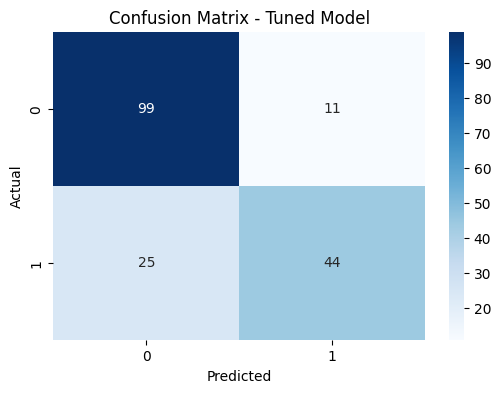

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Tuned Model')

plt.show()

# Conclusion

The model evaluation showed that accuracy alone does not provide a complete picture of classification performance. The baseline Logistic Regression model achieved 80% accuracy, but its recall for the Survived (Class 1) category was 67%, demonstrating why precision, recall, and F1-score are important evaluation metrics.
Using GridSearchCV, multiple combinations of the C and solver hyperparameters were systematically tested with 5-fold cross-validation. The tuned model was then compared with the original model using accuracy, precision, recall, and F1-score.
Overall, this task helped demonstrate that hyperparameter tuning provides a systematic approach to improving machine learning models instead of manually guessing parameter values. It also reinforced the importance of evaluating a classification model using multiple metrics rather than relying only on accuracy.